In [1]:
# Imports.
import numpy as np;
import xarray as xr;
import matplotlib.pyplot as plt;
import h5_reader_xr as reader;
import gysela_utilities as utils;

# Styling.
plt.style.use("ggplot");

In [23]:
from scipy import signal;

In [2]:
#time_step = reader.fetch_data_from_h5("\\home\\thur0011\\GYSELA\\simulations_raw\\GG2019\\delta_zero\\q1.5\\sp0\\Phi2D\\Phi2D_d00000.h5")["deltat"].values;
time_step = reader.fetch_data_from_h5("/home/thur0011/GYSELA/simulations_raw/fresh_batch_7.0/DN_FLUXDRIVEN_GAM_CIRCULARTEST_Q3.5/sp0/Phi2D/Phi2D_d00000.h5")["deltat"].values;
data_arrays = reader.compile_data_from_directory("Phirth_n0", "/home/thur0011/GYSELA/simulations_raw/fresh_batch_7.0/DN_FLUXDRIVEN_GAM_CIRCULARTEST_Q3.5/sp0/Phi2D");

In [2]:
#time_step = reader.fetch_data_from_h5("\\home\\thur0011\\GYSELA\\simulations_raw\\GG2019\\delta_zero\\q1.5\\sp0\\Phi2D\\Phi2D_d00000.h5")["deltat"].values;
time_step = reader.fetch_data_from_h5("/home/thur0011/GYSELA/simulations_raw/fresh_batch_7.0/DN_DAYCASE_DELTASCAN_255X512_Q3.5_-0.3/sp0/Phi2D/Phi2D_d00000.h5")["deltat"].values;
data_arrays = reader.compile_data_from_directory("Phirth_n0", "/home/thur0011/GYSELA/simulations_raw/fresh_batch_7.0/DN_DAYCASE_DELTASCAN_255X512_Q3.5_-0.3/sp0/Phi2D");

<>:36: SyntaxWarning: invalid escape sequence '\d'
<>:36: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_114584/1393492232.py:36: SyntaxWarning: invalid escape sequence '\d'
  plt.title(f"GAM damping & RH residual relaxation (q = 3.5, $\delta = -0.3$, radial index = {radial_index}/255)");


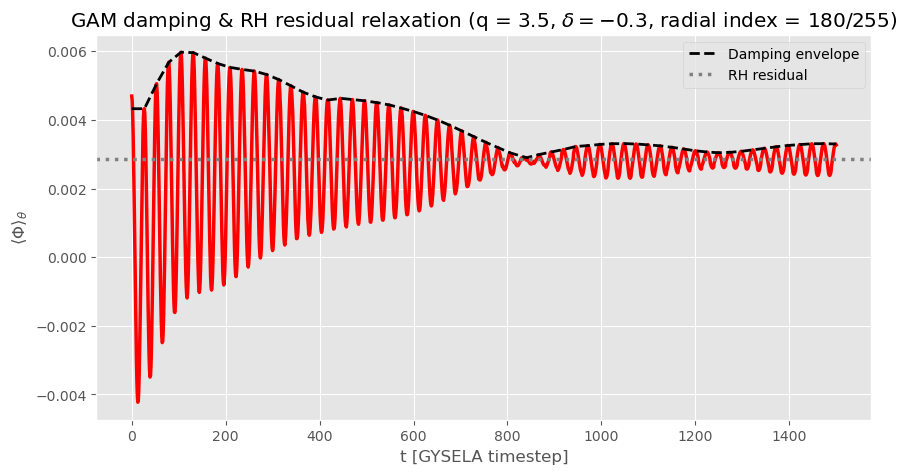

In [11]:

# TODO: below is a detrending method, AI-generated. Remove when done
def plot_flux_driven_gam(phi2D_list, radial_index):

    # 1. Isolate raw signal
    raw_series = utils.generate_poloidally_averaged_time_series(phi2D_list)[:, radial_index].values
    
    # 2. Detrend the signal (Removes the linear/slow drift)
    # Using a butterworth high-pass filter or simply signal.detrend
    detrended_series = signal.detrend(raw_series)
    
    time_range = np.arange(len(detrended_series))

    plt.figure(figsize=(10, 5))
    plt.plot(time_range[145:1000], detrended_series[145:1000], color="red", lw=1.5, alpha=0.8)
    
    # Optional: Plot the original drift in a separate subplot to show the scale difference
    plt.title("Detrended GAM Oscillations (q = 3.5, flux-driven)")
    plt.ylabel(r"$\delta \langle \Phi \rangle_\theta$ (Fluctuations)")
    plt.xlabel("t [GYSELA timestep]")
    plt.grid(True, alpha=0.3)
    plt.show()

def plot_rosenbluth_hinton(phi2D_list, radial_index):
	# Signal isolation and data processing.
	time_series = utils.generate_poloidally_averaged_time_series(phi2D_list)[:, radial_index].values;
	time_range = np.arange(len(time_series));
	amplitude_envelope, residual_level = utils.generate_damping_envelope(time_series);

	# Figure plotting logic.
	plt.figure(figsize = (10, 5));
	plt.plot(time_range, time_series, color = "red", lw = 2.5);
	plt.plot(time_range, amplitude_envelope, color = "black", linestyle = "--", label= "Damping envelope", lw = 2.0);
	plt.axhline(y = residual_level, color = "gray", linestyle = ":", label = f"RH residual", lw = 2.5);
	plt.xlabel("t [GYSELA timestep]");
	plt.ylabel(r"$\langle \Phi \rangle_\theta$");
	plt.title(f"GAM damping & RH residual relaxation (q = 3.5, $\delta = -0.3$, radial index = {radial_index}/255)");
	plt.legend(frameon = True, loc = "upper right");
	plt.show();

# plot_flux_driven_gam(data_arrays, 85);
plot_rosenbluth_hinton(data_arrays, 180);

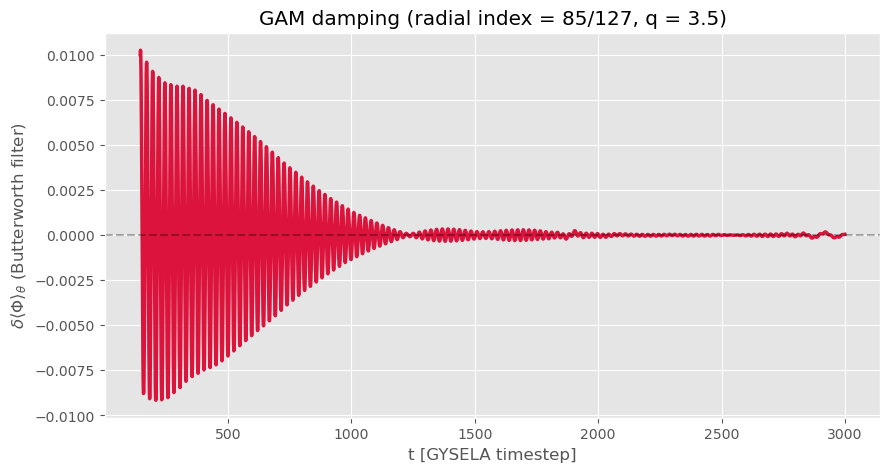

In [41]:
# Entire block below is AI-generated. Test, reproduce, remove when done.
def high_pass_filter_gam(data, timestep, cutoff_hz=200):

    # 1. Determine the sampling frequency (Fs) in Hz
    # Fs = 1 / (dt in seconds). Note: ensure dt is in physical units.
    fs = 1.0 / (timestep * 1e-6) # Assuming GYSELA units are approx microseconds
    
    # 2. Design the Butterworth filter (4th order is usually stable)
    nyquist = 0.5 * fs
    normal_cutoff = cutoff_hz / nyquist
    b, a = signal.butter(4, normal_cutoff, btype='high', analog=False)
    
    # 3. Apply the filter using filtfilt (zero-phase filtering to avoid time-shift)
    filtered_signal = signal.filtfilt(b, a, data)
    return filtered_signal

def plot_refined_flux_driven_gam(phi2D_list, radial_index):
    # Signal isolation
    raw_series = utils.generate_poloidally_averaged_time_series(phi2D_list)[:, radial_index].values
    
    # Apply High-Pass Filter (Cutoff at 200 Hz to kill the ZF drift)
    clean_oscillations = high_pass_filter_gam(raw_series, time_step, cutoff_hz=200)
    
    time_range = np.arange(len(clean_oscillations))

    plt.figure(figsize=(10, 5))
    plt.plot(time_range[145:3000], clean_oscillations[145:3000], color="crimson", lw=2.5)
    plt.axhline(0, color='black', linestyle='--', alpha=0.3)
    
    plt.title(f"GAM damping (radial index = {radial_index}/127, q = 3.5)")
    plt.ylabel(r"$\delta \langle \Phi \rangle_\theta$ (Butterworth filter)")
    plt.xlabel("t [GYSELA timestep]")
    plt.show()
    
plot_refined_flux_driven_gam(data_arrays, 85);